# LoanLens EDA

*Give Me Some Credit* (Kaggle), 150,000 rows, 11 columns. Target `SeriousDlqin2yrs` = borrower went 90+ days delinquent within 2 years.

The point of this notebook is to decide what goes into the model and why. Four questions:

1. How imbalanced is the target, and what does that mean for validation?
2. Which extreme values are broken data, and which are real risk?
3. How much does each variable actually predict? (WoE / IV)
4. What should preprocessing do, in order?

Plot labels are in English because matplotlib without a configured font renders non-Latin text as boxes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

RANDOM_STATE = 42
DATA_DIR = Path("../data")
TARGET = "SeriousDlqin2yrs"

## 1. Load

In [2]:
# first column is an unnamed row id
df = pd.read_csv(DATA_DIR / "raw/cs-training.csv", index_col=0)
df.index.name = "id"

df_test = pd.read_csv(DATA_DIR / "test/cs-test.csv", index_col=0)
df_test.index.name = "id"

print(f"train: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"test : {df_test.shape[0]:,} rows x {df_test.shape[1]} cols")
df.head()

train: 150,000 rows x 11 cols
test : 101,503 rows x 11 cols


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
id,,,,,,,,,,,
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Data dictionary

| Column | Source definition | Type |
|---|---|---|
| `SeriousDlqin2yrs` | target: person experienced 90 days past due delinquency or worse | Y/N |
| `RevolvingUtilizationOfUnsecuredLines` | balance on credit cards and personal lines of credit, excluding real estate and installment debt like car loans, divided by total credit limits | percentage |
| `age` | age of borrower in years | integer |
| `NumberOfTime30-59DaysPastDueNotWorse` | times 30-59 days past due but no worse, **in the last 2 years** | integer |
| `DebtRatio` | monthly debt payments, alimony and **living costs** divided by monthly gross income | percentage |
| `MonthlyIncome` | monthly income | real |
| `NumberOfOpenCreditLinesAndLoans` | open installment loans (car, mortgage) **plus** lines of credit (credit cards) | integer |
| `NumberOfTimes90DaysLate` | times 90 days or more past due | integer |
| `NumberRealEstateLoansOrLines` | mortgage and real estate loans, including home equity lines | integer |
| `NumberOfTime60-89DaysPastDueNotWorse` | times 60-89 days past due but no worse, **in the last 2 years** | integer |
| `NumberOfDependents` | dependents in family, excluding themselves (spouse, children) | integer |

Three details there drive decisions later:

`DebtRatio` includes living costs, not just debt service, so values above 1 are possible for real people and the 35,137 rows above 1 cannot be dismissed as errors (5.3).

`NumberOfTimes90DaysLate` has no stated time window, while the 30-59 and 60-89 counters both say "in the last 2 years". Read literally it is a lifetime count, which matters for leakage (section 8) and explains the weak correlation between the three (section 9).

`RevolvingUtilization` excludes installment debt but `NumberOfOpenCreditLinesAndLoans` includes it, so dividing one by the other mixes two account bases (section 10).

No date column and no lender id, so PSI over time is impossible. Train vs test is the only drift check available.

## 2. Target

SeriousDlqin2yrs
good (0)    139974
bad  (1)     10026

bad rate = 6.6840%   imbalance ratio = 1 : 14.0


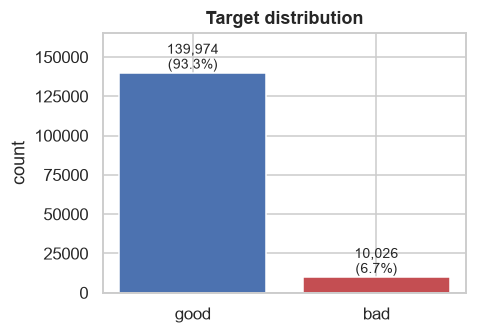

In [3]:
cnt = df[TARGET].value_counts().sort_index()
bad_rate = df[TARGET].mean()

print(cnt.rename({0: "good (0)", 1: "bad  (1)"}).to_string())
print(f"\nbad rate = {bad_rate:.4%}   imbalance ratio = 1 : {cnt[0] / cnt[1]:.1f}")

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.bar(["good", "bad"], cnt.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(cnt.values):
    ax.text(i, v, f"{v:,}\n({v / len(df):.1%})", ha="center", va="bottom", fontsize=9)
ax.set(title="Target distribution", ylabel="count", ylim=(0, cnt.max() * 1.18))
plt.tight_layout()
plt.show()

6.68% bad, ordinary for a retail portfolio. Three consequences.

Accuracy is useless: predicting "good" for everyone scores 93.3%. Use AUC-ROC, KS and Gini, plus PR-AUC if the bad class is the focus.

Every split needs stratifying, CV folds included.

Class weighting and resampling can wait. At 6.7% they are usually unnecessary and they push probabilities out of calibration, which matters if the output has to be a PD.

## 3. Missing values

Missingness in credit data is rarely random, so the bad rate of the missing group is part of the diagnosis.

In [4]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "n_zero": (df == 0).sum(),
})
overview

,dtype,n_missing,missing_pct,n_unique,n_zero
SeriousDlqin2yrs,int64,0,0.00,2,139974
RevolvingUtilizationOfUnsecuredLines,float64,0,0.00,125728,10878
age,int64,0,0.00,86,1
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.00,16,126018
DebtRatio,float64,0,0.00,114194,4113
MonthlyIncome,float64,29731,19.82,13594,1634
NumberOfOpenCreditLinesAndLoans,int64,0,0.00,58,1888
NumberOfTimes90DaysLate,int64,0,0.00,19,141662
NumberRealEstateLoansOrLines,int64,0,0.00,28,56188
NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.00,13,142396


In [5]:
for col in ["MonthlyIncome", "NumberOfDependents"]:
    m = df[col].isna()
    print(f"{col:22s} missing={m.sum():>6,}  bad_rate(missing)={df.loc[m, TARGET].mean():.4f}"
          f"   bad_rate(present)={df.loc[~m, TARGET].mean():.4f}")

both = df.MonthlyIncome.isna() & df.NumberOfDependents.isna()
print(f"\nmissing in both: {both.sum():,}")
print(f"every NumberOfDependents gap sits inside a MonthlyIncome gap: "
      f"{both.sum() == df.NumberOfDependents.isna().sum()}")

MonthlyIncome          missing=29,731  bad_rate(missing)=0.0561   bad_rate(present)=0.0695
NumberOfDependents     missing= 3,924  bad_rate(missing)=0.0456   bad_rate(present)=0.0674

missing in both: 3,924
every NumberOfDependents gap sits inside a MonthlyIncome gap: True


`MonthlyIncome` is missing in 19.82% of rows. High, but well under the 50-60% range where dropping a column is standard, so it gets imputed with a flag instead.

`NumberOfDependents` is missing in 2.62%, and every one of those 3,924 rows also has no income. One block of personal data absent, not two independent gaps.

Both missing groups have a *lower* bad rate than average (5.61% vs 6.95% for income, 4.56% for dependents), so missingness carries information. Dropping the rows would throw it away, and so would an imputation that blends them into everyone else. Keep `income_missing` as a feature and impute with the median, since income is heavily right skewed.

## 4. Descriptive statistics

In [6]:
df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).T

,count,mean,std,min,1%,25%,50%,75%,90%,95%,99%,99.9%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.0,0.029867,0.154181,0.559046,0.981278,1.0,1.092956,1571.006,50708.0
age,150000.0,52.295207,14.771866,0.0,24.0,41.000000,52.000000,63.000000,72.000000,78.0,87.000000,94.000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.0,0.000000,0.000000,0.000000,1.000000,2.0,4.000000,98.000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.0,0.175074,0.366508,0.868254,1267.000000,2449.0,4979.040000,10613.074,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,0.0,3400.000000,5400.000000,8249.000000,11666.000000,14587.6,25000.000000,78395.748,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,0.0,5.000000,8.000000,11.000000,15.000000,18.0,24.000000,34.000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,3.000000,98.000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.0,0.000000,1.000000,2.000000,2.000000,3.0,4.000000,9.000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,2.000000,98.000,98.0


Three things stand out, each handled below.

`RevolvingUtilizationOfUnsecuredLines` maxes at 50,708 with P95 at 1.0. A ratio bounded at 0-1 should not reach five figures.

`DebtRatio` maxes at 329,664 with a median of 0.37, so the large values are not in ratio units.

All three delinquency counters max at 98, and P99.9 is also 98. That is a code, not a count.

## 5. Data quality

The rule used throughout this section: if an extreme value comes with a *higher* bad rate, it is real risk and stays. If the bad rate is flat or lower than average, the value is broken and becomes missing.

### 5.1 The 96 / 98 codes

In [7]:
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

print("upper tail of each counter:")
for c in late_cols:
    print(f"  {c:38s} {dict(df[c].value_counts().sort_index().tail(6))}")

sentinel = df[late_cols].isin([96, 98]).any(axis=1)
print(f"\nrows hitting 96/98: {sentinel.sum():,} ({sentinel.mean():.3%})")
print(f"bad rate there: {df.loc[sentinel, TARGET].mean():.4f}  (overall {bad_rate:.4f})")
print(f"all three counters equal on those rows: {df.loc[sentinel, late_cols].nunique(axis=1).eq(1).all()}")
print(f"rows coded in all three columns: {df[late_cols].isin([96, 98]).all(axis=1).sum():,}")

upper tail of each counter:
  NumberOfTime30-59DaysPastDueNotWorse   {10: np.int64(4), 11: np.int64(1), 12: np.int64(2), 13: np.int64(1), 96: np.int64(5), 98: np.int64(264)}
  NumberOfTimes90DaysLate                {13: np.int64(4), 14: np.int64(2), 15: np.int64(2), 17: np.int64(1), 96: np.int64(5), 98: np.int64(264)}
  NumberOfTime60-89DaysPastDueNotWorse   {7: np.int64(9), 8: np.int64(2), 9: np.int64(1), 11: np.int64(1), 96: np.int64(5), 98: np.int64(264)}

rows hitting 96/98: 269 (0.179%)
bad rate there: 0.5465  (overall 0.0668)


all three counters equal on those rows: True
rows coded in all three columns: 269


269 rows carry 96 or 98, all three counters always hold the same value, and nothing sits between 13 and 96. These are status codes (96 = no data, 98 = refinanced or declined), not counts.

Their bad rate is 54.65%, eight times overall, making the code itself the strongest single signal here. Converting 98 to NaN and stopping would discard that, which is why `late_code_flag` exists.

### 5.2 Utilization above 1

    1 < ru <= 2      n= 2,950  bad_rate=0.4010
    2 < ru <= 10     n=   130  bad_rate=0.2846
   10 < ru <= 13     n=     3  bad_rate=1.0000
   13 < ru <= inf    n=   238  bad_rate=0.0588

max = 50,708   P99 = 1.093   P99.9 = 1,571.0


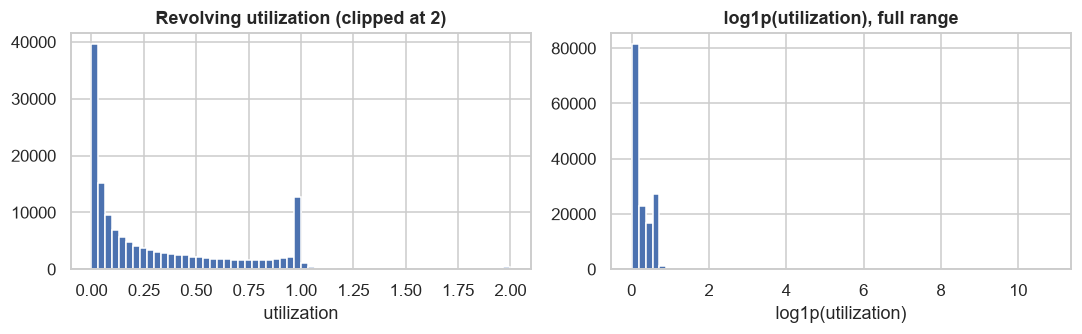

In [8]:
ru = df.RevolvingUtilizationOfUnsecuredLines
for lo, hi in [(1, 2), (2, 10), (10, 13), (13, np.inf)]:
    m = (ru > lo) & (ru <= hi)
    print(f"  {lo:>3} < ru <= {hi:<6} n={m.sum():>6,}  bad_rate={df.loc[m, TARGET].mean():.4f}")
print(f"\nmax = {ru.max():,.0f}   P99 = {ru.quantile(0.99):.3f}   P99.9 = {ru.quantile(0.999):,.1f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(ru.clip(upper=2), bins=60, color="#4c72b0")
axes[0].set(title="Revolving utilization (clipped at 2)", xlabel="utilization")
axes[1].hist(np.log1p(ru), bins=60, color="#4c72b0")
axes[1].set(title="log1p(utilization), full range", xlabel="log1p(utilization)")
plt.tight_layout()
plt.show()

Utilization between 1 and 2 (n=2,950) has a 40.1% bad rate. Genuinely over the limit and genuinely risky, so it stays.

Above 13 (n=238) the bad rate is 5.88%, *below* the overall rate. If those values meant anything about risk the rate would spike, not dip. They are errors, most likely a zero or mis-scaled credit limit, so they become NaN. A log transform would hide the shape of the problem while keeping the bad ordering intact, which is worse than capping or nulling.

### 5.3 DebtRatio carries two different units

In [9]:
dr = df.DebtRatio
inc_na = df.MonthlyIncome.isna()

print(f"DebtRatio > 1  : {(dr > 1).sum():,}")
print(f"DebtRatio > 10 : {(dr > 10).sum():,}")
print(f"  of which MonthlyIncome is also missing: {((dr > 10) & inc_na).sum():,} "
      f"({((dr > 10) & inc_na).sum() / (dr > 10).sum():.1%})")

print("\ncrosstab: DebtRatio > 10  x  MonthlyIncome missing")
print(pd.crosstab(dr > 10, inc_na, rownames=["DebtRatio>10"], colnames=["income_missing"]))

print(f"\nbad rate, DebtRatio > 10 : {df.loc[dr > 10, TARGET].mean():.4f}")
print(f"bad rate, DebtRatio <= 1 : {df.loc[dr <= 1, TARGET].mean():.4f}")

DebtRatio > 1  : 35,137
DebtRatio > 10 : 28,877
  of which MonthlyIncome is also missing: 26,771 (92.7%)

crosstab: DebtRatio > 10  x  MonthlyIncome missing
income_missing   False  True 
DebtRatio>10                 
False           118163   2960
True              2106  26771

bad rate, DebtRatio > 10 : 0.0557
bad rate, DebtRatio <= 1 : 0.0673


The threshold is 10, not 1, because the source definition puts living costs in the numerator. Spending more than you earn is a real situation, so the 35,137 rows above 1 are not automatically wrong. The four and five figure values are what needs explaining.

Of the 28,877 rows above 10, 26,771 (92.7%) are also missing income. Too systematic to be coincidence: with no denominator available the source system recorded the monthly *amount* in the same field. One column, two units. The bad rate agrees, 5.6% above 10 against 6.7% below 1, so those values are not describing debt burden at all.

Capping would turn "spends 2,449 a month" into "owes 2,449x income", a different claim entirely. Splitting into `debt_ratio` and `debt_amount`, switched by `income_missing`, keeps both groups intact.

### 5.4 Impossible values and duplicates

In [10]:
print(f"age == 0            : {(df.age == 0).sum():,}")
print(f"age < 18            : {(df.age < 18).sum():,}   (min={df.age.min()}, max={df.age.max()})")
print(f"MonthlyIncome == 0  : {(df.MonthlyIncome == 0).sum():,}")
print(f"MonthlyIncome < 100 : {(df.MonthlyIncome < 100).sum():,}")
print(f"  bad rate at income == 0: {df.loc[df.MonthlyIncome == 0, TARGET].mean():.4f}")

dup = df.duplicated()
print(f"\nfully duplicated rows (index excluded): {dup.sum():,}")
print(f"  bad rate there: {df.loc[dup, TARGET].mean():.4f}")
print(f"max NumberOfDependents: {df.NumberOfDependents.max():.0f}")

age == 0            : 1
age < 18            : 1   (min=0, max=109)
MonthlyIncome == 0  : 1,634
MonthlyIncome < 100 : 2,277
  bad rate at income == 0: 0.0404

fully duplicated rows (index excluded): 609
  bad rate there: 0.0279
max NumberOfDependents: 20


One row has `age = 0`. Impossible, not worth dropping a row over, so it becomes NaN.

1,634 rows have zero income, which can be true (unemployed, retired) or a placeholder for missing, and nothing in the data separates the two. Keep them and add `income_zero`.

609 rows are exact duplicates across all columns. With no customer id there is no telling repeated records from two people who genuinely match, plausible when most variables are small integers. Keep them, but do not let them straddle the train/test boundary or validation scores come out optimistic.

### 5.5 Cleaning

Every decision below traces back to 5.1-5.4. No rows are removed.

In [11]:
def clean(data: pd.DataFrame) -> pd.DataFrame:
    """Null out sentinels and impossible values, keeping each signal as a flag."""
    out = data.copy()

    # 5.1 status codes -> NaN, signal preserved as a flag
    out["late_code_flag"] = out[late_cols].isin([96, 98]).any(axis=1).astype("int8")
    for c in late_cols:
        out[c] = out[c].astype("float64")
        out.loc[out[c].isin([96, 98]), c] = np.nan

    # 5.2 utilization values that contradict their own bad rate
    out["util_invalid_flag"] = (out.RevolvingUtilizationOfUnsecuredLines > 13).astype("int8")
    out.loc[out.RevolvingUtilizationOfUnsecuredLines > 13, "RevolvingUtilizationOfUnsecuredLines"] = np.nan

    # 5.3 split DebtRatio by unit, using income presence as the switch
    out["income_missing"] = out.MonthlyIncome.isna().astype("int8")
    out["debt_ratio"] = out.DebtRatio.where(out.income_missing == 0)
    out["debt_amount"] = out.DebtRatio.where(out.income_missing == 1)

    # 5.4
    out["age"] = out.age.astype("float64")
    out.loc[out.age < 18, "age"] = np.nan
    out["income_zero"] = (out.MonthlyIncome == 0).astype("int8")

    return out


df_clean = clean(df)
print(f"df_clean: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} cols  "
      f"(row count unchanged: {df_clean.shape[0] == df.shape[0]})")
df_clean[["late_code_flag", "util_invalid_flag", "income_missing", "income_zero"]].sum()

df_clean: 150,000 rows x 17 cols  (row count unchanged: True)


late_code_flag         269
util_invalid_flag      238
income_missing       29731
income_zero           1634
dtype: int64

## 6. Distributions

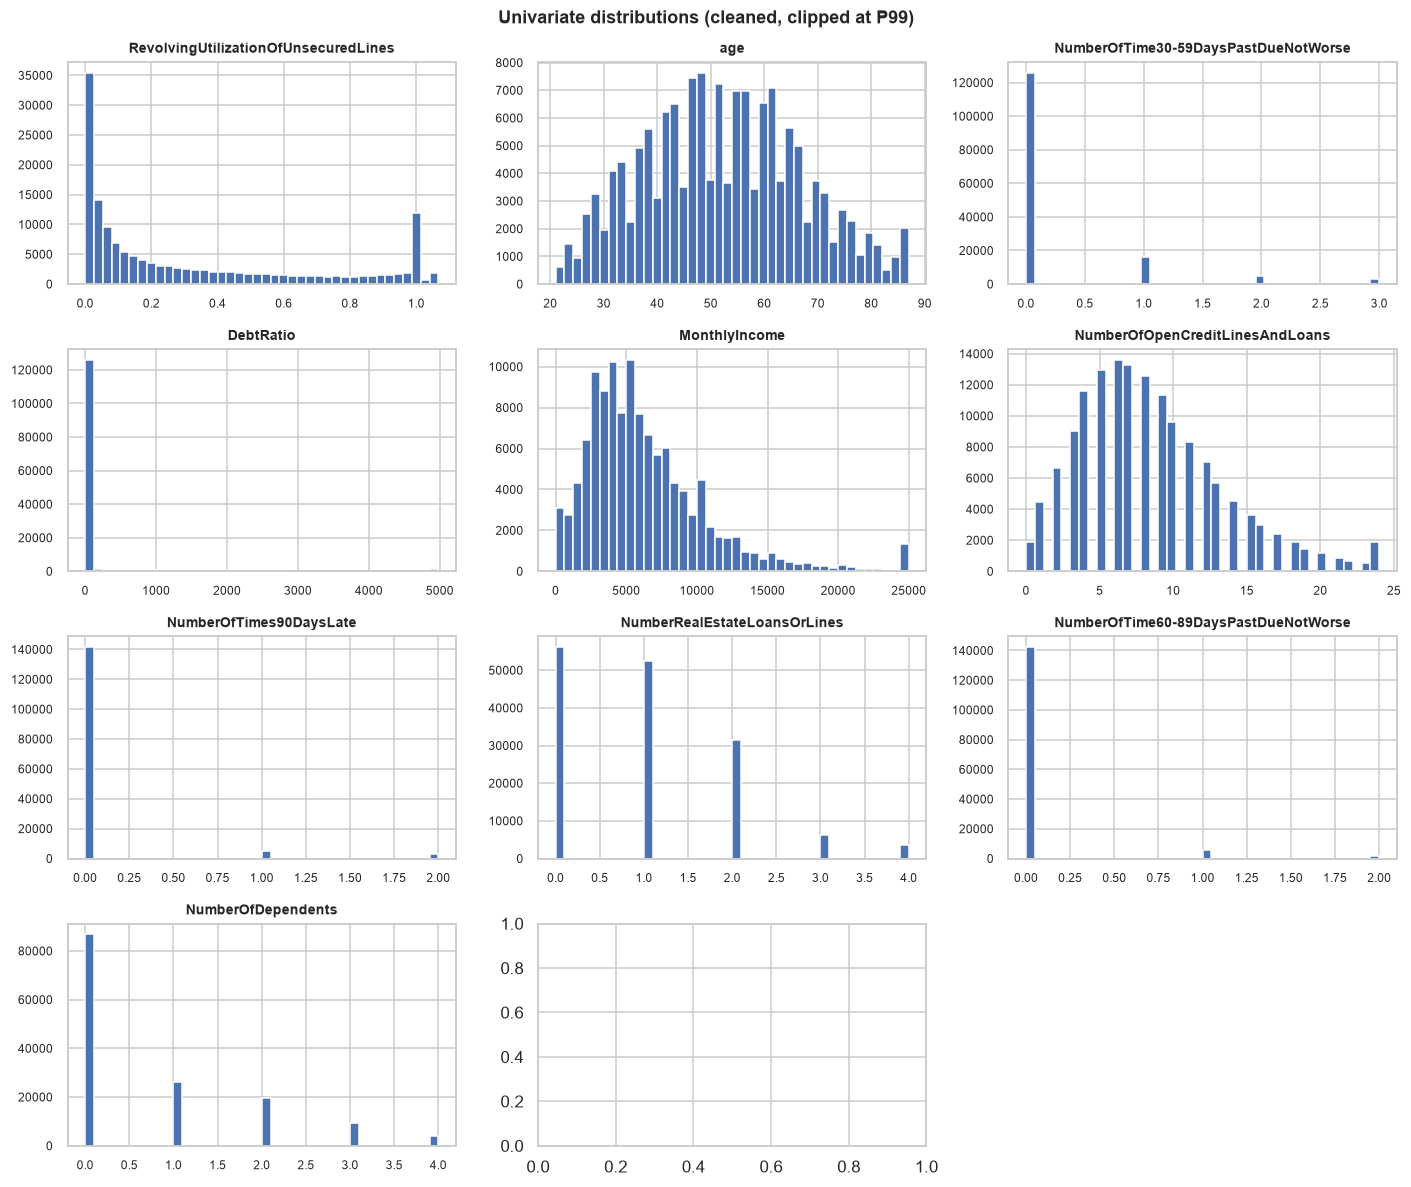

skewness after cleaning:
MonthlyIncome                           114.04
DebtRatio                                95.16
NumberOfTimes90DaysLate                   9.33
NumberOfTime60-89DaysPastDueNotWorse      7.55
NumberOfTime30-59DaysPastDueNotWorse      4.25
NumberRealEstateLoansOrLines              3.48
RevolvingUtilizationOfUnsecuredLines      2.16
NumberOfDependents                        1.59
NumberOfOpenCreditLinesAndLoans           1.22
age                                       0.19


In [12]:
num_cols = [c for c in df.columns if c != TARGET]
fig, axes = plt.subplots(4, 3, figsize=(13, 11))

for ax, c in zip(axes.ravel(), num_cols):
    s = df_clean[c].dropna()
    # clipped at P99 so the bulk of the data is visible
    ax.hist(s.clip(upper=s.quantile(0.99)), bins=40, color="#4c72b0")
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=8)

axes.ravel()[-1].axis("off")
fig.suptitle("Univariate distributions (cleaned, clipped at P99)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("skewness after cleaning:")
print(df_clean[num_cols].skew().sort_values(ascending=False).round(2).to_string())

Everything is strongly right skewed except `age` at 0.19.

Tree models do not care, so raw values are fine for LightGBM or XGBoost. Logistic regression and scorecards do, and the standard fix here is WoE binning rather than a log transform, since binning handles skew, missing values and non-monotonic shape in one step.

## 7. Bad rate by bin

What to look for is whether the direction is consistent, since a scorecard wants monotonic relationships.

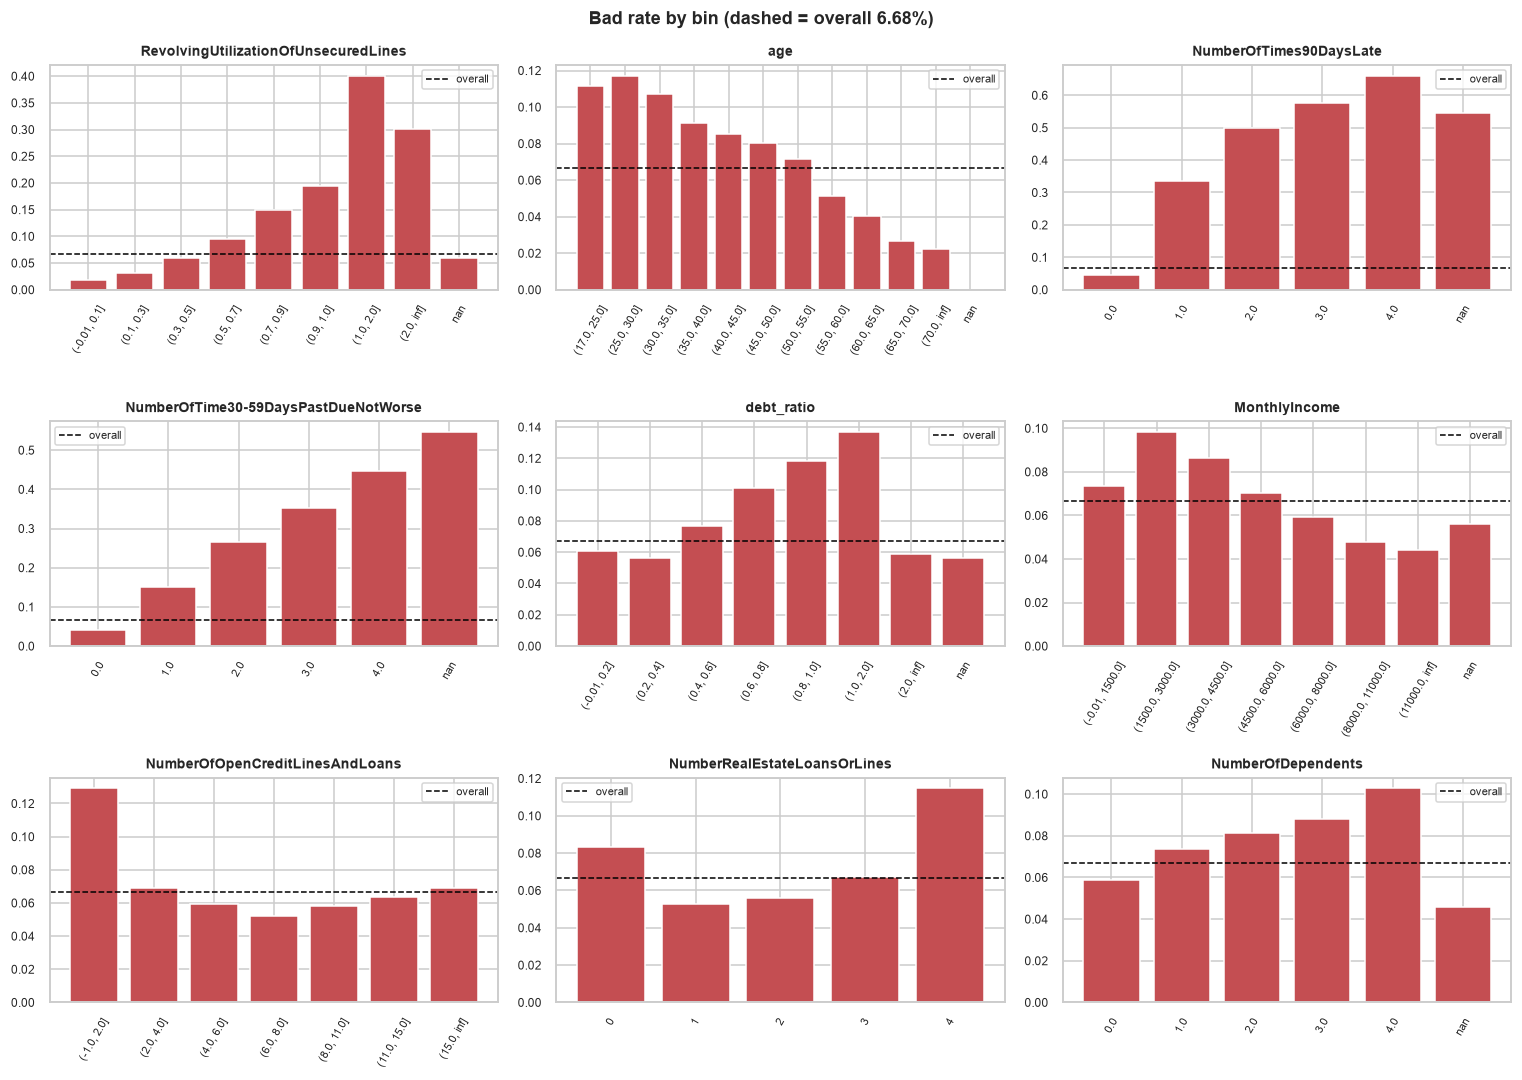

In [13]:
def bad_rate_by_bin(data, col, bins=None, q=8, clip=None):
    """Bad rate per bin. Quantile bins if no edges given; NaN kept as its own bin."""
    s = data[col]
    if clip is not None:
        s = s.clip(upper=clip)
    if bins is not None:
        b = pd.cut(s, bins)
    elif isinstance(s.dtype, pd.CategoricalDtype) or s.nunique() <= 10:
        b = s
    else:
        b = pd.qcut(s, q, duplicates="drop")
    g = data.groupby(b, observed=False, dropna=False)[TARGET].agg(n="size", bad="sum")
    g = g[g.n > 0]
    g["bad_rate"] = g.bad / g.n
    return g


plot_specs = [
    ("RevolvingUtilizationOfUnsecuredLines", [-0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1, 2, np.inf]),
    ("age", [17, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, np.inf]),
    ("NumberOfTimes90DaysLate", None),
    ("NumberOfTime30-59DaysPastDueNotWorse", None),
    ("debt_ratio", [-0.01, 0.2, 0.4, 0.6, 0.8, 1, 2, np.inf]),
    ("MonthlyIncome", [-0.01, 1500, 3000, 4500, 6000, 8000, 11000, np.inf]),
    ("NumberOfOpenCreditLinesAndLoans", [-1, 2, 4, 6, 8, 11, 15, np.inf]),
    ("NumberRealEstateLoansOrLines", None),
    ("NumberOfDependents", None),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, (col, bins) in zip(axes.ravel(), plot_specs):
    clip = 4 if bins is None else None
    g = bad_rate_by_bin(df_clean, col, bins=bins, clip=clip)
    ax.bar([str(i) for i in g.index], g.bad_rate, color="#c44e52")
    ax.axhline(bad_rate, ls="--", lw=1, color="black", label="overall")
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=7)

fig.suptitle("Bad rate by bin (dashed = overall 6.68%)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
print("### RevolvingUtilizationOfUnsecuredLines")
print(bad_rate_by_bin(df_clean, "RevolvingUtilizationOfUnsecuredLines",
                      bins=[-0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1, 2, np.inf]))
print("\n### NumberOfTimes90DaysLate (clip 3)")
print(bad_rate_by_bin(df_clean, "NumberOfTimes90DaysLate", clip=3))

### RevolvingUtilizationOfUnsecuredLines
                                          n   bad  bad_rate
RevolvingUtilizationOfUnsecuredLines                       
(-0.01, 0.1]                          64404  1166  0.018104
(0.1, 0.3]                            28478   895  0.031428
(0.3, 0.5]                            15830   926  0.058497
(0.5, 0.7]                            11340  1085  0.095679
(0.7, 0.9]                             9879  1468  0.148598
(0.9, 1.0]                            16748  3249  0.193993
(1.0, 2.0]                             2950  1183  0.401017
(2.0, inf]                              133    40  0.300752
NaN                                     238    14  0.058824

### NumberOfTimes90DaysLate (clip 3)
                              n   bad  bad_rate
NumberOfTimes90DaysLate                        
0.0                      141662  6554  0.046265
1.0                        5243  1765  0.336639
2.0                        1555   776  0.499035
3.0                  

Utilization climbs from 1.8% below 0.1 to 40.1% in the 1-2 band, then drops back to 30.1% above 2.0. That last bin holds 133 rows, far too few to read as a real reversal, so the two get merged downstream.

The counters climb fastest of anything here, hitting 61.7% at three or more 90-day events.

Age is close to monotonic but not quite: it peaks at 25-30 (11.7%) rather than at the youngest band (11.2%), then falls to 2.3% past 70. Merging everything under 30 into one bin fixes it and matches a band a credit officer already thinks in.

`debt_ratio` rises weakly to 1 then flattens. `MonthlyIncome` has the same kind of kink as age, with the lowest band (under 1,500) sitting below the 1,500-3,000 band above it.

Two variables are U shaped. `NumberOfOpenCreditLinesAndLoans` is worst at 2 accounts or fewer (12.9%, thin file), dips, then ticks up at the top. `NumberRealEstateLoansOrLines` runs 8.3% at zero, safest at exactly one (5.3%), back to 11.5% at four or more.

Those two are why binning is not optional. Fed in raw they get near-zero coefficients in a logistic regression and look worthless, when they separate risk well.

The bin edges used above are exploratory. Where a tail turned out too thin to estimate from, the final edges in `src/config.py` merge it, and `WoEBinner.is_monotonic` checks the result in code rather than leaving it to whoever reads this.

## 8. WoE and IV

Per bin: $\mathrm{WoE}_i = \ln(\%\text{good}_i / \%\text{bad}_i)$, positive meaning safer than average.

Per variable: $\mathrm{IV} = \sum_i (\%\text{good}_i - \%\text{bad}_i) \cdot \mathrm{WoE}_i$

Both sign conventions are in use and IV comes out identical either way, since
flipping the ratio flips both factors in the product. This notebook uses good
over bad so WoE runs in the same direction as the final credit score, where a
higher number means lower risk. Mixing the two conventions inside one project
inverts the scorecard silently, with no error raised.

Conventional reading: below 0.02 useless, 0.02-0.1 weak, 0.1-0.3 medium, 0.3-0.5 strong, above 0.5 strong enough to go looking for leakage.

In [15]:
def woe_table(data, col, bins=None, q=8, clip=None, eps=0.5):
    """WoE/IV per bin. eps is a Haldane correction for bins with no bads."""
    g = bad_rate_by_bin(data, col, bins=bins, q=q, clip=clip)
    g["good"] = g.n - g.bad
    dist_bad = (g.bad + eps) / (g.bad.sum() + eps * len(g))
    dist_good = (g.good + eps) / (g.good.sum() + eps * len(g))
    # good over bad, so positive WoE means safer. See the note above on convention.
    g["woe"] = np.log(dist_good / dist_bad)
    g["iv_part"] = (dist_good - dist_bad) * g.woe
    out = g[["n", "bad", "bad_rate", "woe", "iv_part"]].copy()
    out.attrs["iv"] = float(g.iv_part.sum())
    return out


specs = {
    "RevolvingUtilization":  dict(col="RevolvingUtilizationOfUnsecuredLines",
                                  bins=[-0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1, 2, np.inf]),
    "age":                   dict(col="age", bins=[17, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, np.inf]),
    "late_90":               dict(col="NumberOfTimes90DaysLate", clip=3),
    "late_30_59":            dict(col="NumberOfTime30-59DaysPastDueNotWorse", clip=4),
    "late_60_89":            dict(col="NumberOfTime60-89DaysPastDueNotWorse", clip=2),
    "debt_ratio":            dict(col="debt_ratio", bins=[-0.01, 0.2, 0.4, 0.6, 0.8, 1, 2, np.inf]),
    "MonthlyIncome":         dict(col="MonthlyIncome", bins=[-0.01, 1500, 3000, 4500, 6000, 8000, 11000, np.inf]),
    "open_credit_lines":     dict(col="NumberOfOpenCreditLinesAndLoans", bins=[-1, 2, 4, 6, 8, 11, 15, np.inf]),
    "real_estate_loans":     dict(col="NumberRealEstateLoansOrLines", clip=4),
    "dependents":            dict(col="NumberOfDependents", clip=4),
    "late_code_flag":        dict(col="late_code_flag"),
    "income_missing":        dict(col="income_missing"),
}

tables = {name: woe_table(df_clean, **kw) for name, kw in specs.items()}
iv_rank = (pd.Series({n: t.attrs["iv"] for n, t in tables.items()})
             .sort_values(ascending=False).rename("IV").to_frame())
iv_rank["strength"] = pd.cut(iv_rank.IV, [-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
                             labels=["useless", "weak", "medium", "strong", "very strong"])
iv_rank.round(4)

,IV,strength
RevolvingUtilization,1.1503,very strong
late_90,0.8783,very strong
late_30_59,0.7604,very strong
late_60_89,0.5993,very strong
age,0.2568,medium
open_credit_lines,0.0805,weak
MonthlyIncome,0.0743,weak
debt_ratio,0.0717,weak
real_estate_loans,0.0617,weak
late_code_flag,0.0392,weak


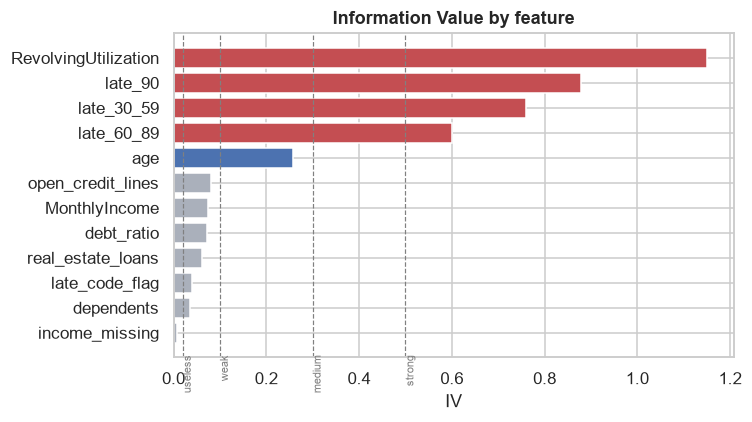

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#c44e52" if v > 0.5 else "#4c72b0" if v > 0.1 else "#aab0bb" for v in iv_rank.IV]
ax.barh(list(iv_rank.index[::-1]), iv_rank.IV[::-1], color=colors[::-1])
for th, lab in [(0.02, "useless"), (0.1, "weak"), (0.3, "medium"), (0.5, "strong")]:
    ax.axvline(th, ls="--", lw=0.8, color="gray")
    ax.text(th, -0.9, lab, fontsize=7, rotation=90, va="top", color="gray")
ax.set(title="Information Value by feature", xlabel="IV")
plt.tight_layout()
plt.show()

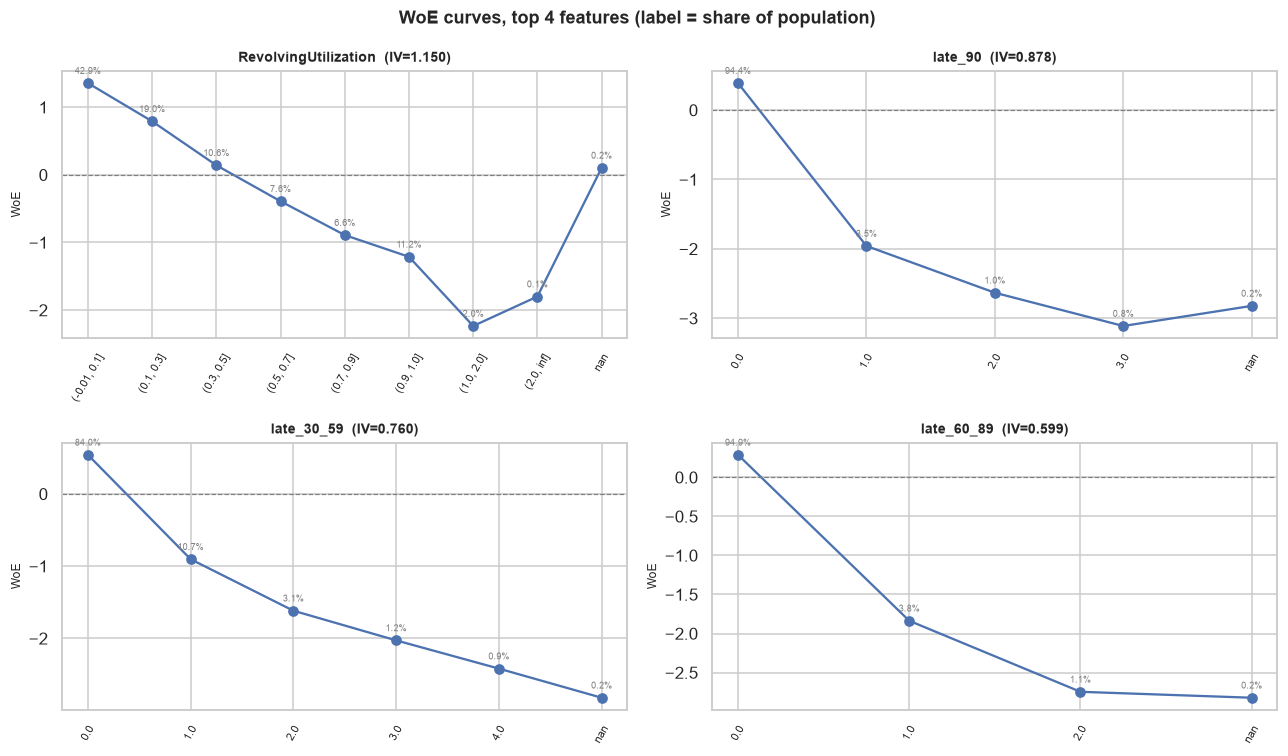

In [17]:
# WoE curves for the top four, to check monotonicity and bin population
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, name in zip(axes.ravel(), iv_rank.index[:4]):
    t = tables[name]
    ax.plot([str(i) for i in t.index], t.woe, marker="o", color="#4c72b0")
    ax.axhline(0, ls="--", lw=0.8, color="gray")
    ax.set_title(f"{name}  (IV={t.attrs['iv']:.3f})", fontsize=9)
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.set_ylabel("WoE", fontsize=8)
    for xi, (w, n) in enumerate(zip(t.woe, t.n)):
        ax.annotate(f"{n / len(df_clean):.1%}", (xi, w), fontsize=6,
                    textcoords="offset points", xytext=(0, 6), ha="center", color="gray")
fig.suptitle("WoE curves, top 4 features (label = share of population)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Ranking: `RevolvingUtilization` 1.15, `late_90` 0.88, `late_30_59` 0.76, `late_60_89` 0.60, `age` 0.26, and everything else under 0.09.

### Is anything above 0.5 leakage?

Not for utilization or the two counters with a stated 2-year window. Those are bureau facts known at application time, and past delinquency predicting future delinquency is the normal shape of a credit model.

`late_90` needs a caveat. Its definition carries no window while the other two explicitly do, and the target is delinquency within 2 years. If the two periods overlap, this is leakage outright. The data argues they do not: an overlapping counter would make nearly everyone with `late_90 > 0` a bad, and the observed rates run 33.7% at one event to 61.7% at three or more. High, but far from certain. Usable, then, though that rests on a documentation gap rather than anything the data settles, so it is worth asking the data owner early.

Two consequences to plan around. The model will lean on five variables and the other six will barely move AUC. And capacity is weak: `debt_ratio` 0.072, `MonthlyIncome` 0.074, roughly ten times below the behavioural features, which matches real portfolios.

The two flags from section 5 differ. `late_code_flag` reaches 0.039 off 0.18% of the population, good value given IV already weights by population size. `income_missing` reaches 0.008, useless alone, which does not contradict section 3: a 5.6% vs 7.0% gap predicts nothing by itself. It stays because it tells the model which unit `DebtRatio` is in, not for its IV.

## 9. Correlation

Spearman rather than Pearson, since the variables are skewed and outliers would drag a Pearson estimate around.

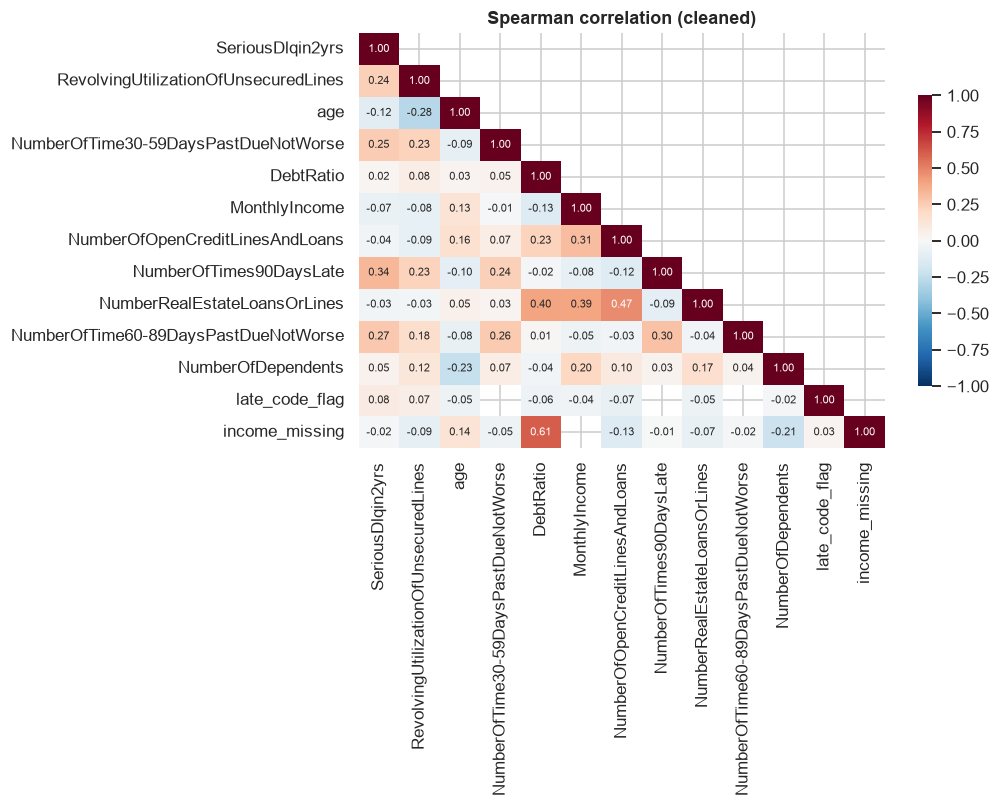

In [18]:
corr_cols = num_cols + ["late_code_flag", "income_missing"]
corr = df_clean[[TARGET] + corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation (cleaned)", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
print("correlation with target, by absolute value:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3).to_string())

c = corr.drop(index=TARGET, columns=TARGET).abs()
c.values[np.tril_indices_from(c)] = np.nan
pairs = c.unstack().dropna().sort_values(ascending=False)
print("\nmost correlated pairs:")
print(pairs.head(8).round(3).to_string())
print(f"\npairs above 0.8: {(pairs > 0.8).sum()}")

correlation with target, by absolute value:
NumberOfTimes90DaysLate                 0.335
NumberOfTime60-89DaysPastDueNotWorse    0.268
NumberOfTime30-59DaysPastDueNotWorse    0.251
RevolvingUtilizationOfUnsecuredLines    0.241
age                                    -0.117
late_code_flag                          0.081
MonthlyIncome                          -0.067
NumberOfDependents                      0.046
NumberOfOpenCreditLinesAndLoans        -0.039
NumberRealEstateLoansOrLines           -0.034
income_missing                         -0.021
DebtRatio                               0.021

most correlated pairs:
income_missing                        DebtRatio                               0.605
NumberRealEstateLoansOrLines          NumberOfOpenCreditLinesAndLoans         0.473
                                      DebtRatio                               0.400
                                      MonthlyIncome                           0.391
NumberOfOpenCreditLinesAndLoans       Monthl

Nothing exceeds 0.8. The top pair, `income_missing` with `DebtRatio` at 0.61, is section 5.3 showing up again rather than a real relationship: the inflated DebtRatio values track missing income systematically, and fed in raw together they would compete to explain the same thing. Then `NumberRealEstateLoansOrLines` with `NumberOfOpenCreditLinesAndLoans` at 0.47, expected since a mortgage is also an open loan, and the same variable with `DebtRatio` at 0.40.

The three counters correlate only 0.24 to 0.30 with each other, lower than expected. Frequent 30-day lateness is a different population from frequent 90-day lateness, so all three stay. Nothing needs dropping for collinearity, though VIF is worth rechecking after WoE, since binning changes the structure.

Correlation with the target tops out at 0.34 while IV passes 1.0. Not a contradiction: correlation measures a monotonic linear association and IV does not, which is why screening here uses IV.

## 10. Engineered features

Built from what the sections above suggested, then measured by IV instead of assumed to help.

In [20]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # delinquency history, summed and severity weighted
    out["total_late"] = out[late_cols].sum(axis=1, min_count=1)
    out["weighted_late"] = (1 * out["NumberOfTime30-59DaysPastDueNotWorse"]
                            + 2 * out["NumberOfTime60-89DaysPastDueNotWorse"]
                            + 3 * out["NumberOfTimes90DaysLate"])
    out["has_late"] = (out["total_late"] > 0).astype("int8")

    # account mix, aimed at the U shapes in section 7.
    # Not called "unsecured": NumberOfOpenCreditLinesAndLoans includes car loans,
    # which are secured, so the name follows what the number actually is.
    out["non_realestate_lines"] = (out.NumberOfOpenCreditLinesAndLoans
                                   - out.NumberRealEstateLoansOrLines).clip(lower=0)
    out["real_estate_share"] = (out.NumberRealEstateLoansOrLines
                                / out.NumberOfOpenCreditLinesAndLoans.replace(0, np.nan))

    # repayment capacity
    out["income_per_person"] = out.MonthlyIncome / (out.NumberOfDependents.fillna(0) + 1)
    out["monthly_debt"] = out.debt_ratio * out.MonthlyIncome
    out["disposable_income"] = out.MonthlyIncome - out["monthly_debt"]

    # numerator excludes installment debt, denominator includes it (section 1),
    # so this is expected to underperform raw utilization. Built to confirm that with IV.
    out["util_per_line"] = (out.RevolvingUtilizationOfUnsecuredLines
                            / out.NumberOfOpenCreditLinesAndLoans.replace(0, np.nan))

    # household size = dependents + self
    out["family_size"] = out.NumberOfDependents + 1
    out["family_size_group"] = pd.cut(
        out["family_size"],
        bins=[0, 2, 4, 6, np.inf],
        labels=["Small (1-2)", "Medium (3-4)", "Large (5-6)", "Very Large (7+)"],
        ordered=True,
    )
    return out


df_feat = add_features(df_clean)
new_cols = ["total_late", "weighted_late", "has_late", "non_realestate_lines", "real_estate_share",
            "income_per_person", "monthly_debt", "disposable_income", "util_per_line", "family_size"]
df_feat[new_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
total_late,149731.0,0.401,1.102,0.000,0.000,0.000,0.000,19.000
weighted_late,149731.0,0.647,2.082,0.000,0.000,0.000,0.000,51.000
has_late,150000.0,0.201,0.400,0.000,0.000,0.000,0.000,1.000
non_realestate_lines,150000.0,7.435,4.766,0.000,4.000,7.000,10.000,57.000
real_estate_share,148112.0,0.123,0.136,0.000,0.000,0.100,0.200,1.000
income_per_person,120269.0,4509.235,8884.018,0.000,1960.000,3333.333,5658.000,1794060.000
monthly_debt,120269.0,2117.749,4196.596,0.000,595.283,1619.791,2879.731,478450.559
disposable_income,120269.0,4552.472,14585.553,-467416.288,1941.253,3567.023,5867.348,3004327.002
util_per_line,147874.0,0.071,0.160,0.000,0.004,0.018,0.065,6.000
family_size,146076.0,1.757,1.115,1.000,1.000,1.000,2.000,21.000


In [21]:
# each new feature against the baseline it was derived from
new_specs = {
    "weighted_late":     dict(col="weighted_late", clip=6),
    "total_late":        dict(col="total_late", clip=4),
    "has_late":          dict(col="has_late"),
    "util_per_line":     dict(col="util_per_line", q=8),
    "income_per_person": dict(col="income_per_person", q=8),
    "disposable_income": dict(col="disposable_income", q=8),
    "monthly_debt":      dict(col="monthly_debt", q=8),
    "real_estate_share": dict(col="real_estate_share", q=6),
    "non_realestate_lines": dict(col="non_realestate_lines", bins=[-1, 2, 4, 6, 8, 11, 15, np.inf]),
    "family_size_group": dict(col="family_size_group"),
}
new_iv = pd.Series({n: woe_table(df_feat, **kw).attrs["iv"] for n, kw in new_specs.items()})

cmp = pd.DataFrame({
    "IV_new": new_iv,
    "baseline": ["late_90", "late_90", "late_90", "RevolvingUtilization", "MonthlyIncome",
                 "MonthlyIncome", "debt_ratio", "real_estate_loans", "open_credit_lines", "dependents"],
})
cmp["IV_baseline"] = cmp.baseline.map(iv_rank.IV)
cmp["delta"] = cmp.IV_new - cmp.IV_baseline
cmp["verdict"] = np.where(cmp.delta > 0.01, "keep", np.where(cmp.delta > -0.01, "neutral", "drop"))
cmp.sort_values("delta", ascending=False).round(4)

,IV_new,baseline,IV_baseline,delta,verdict
weighted_late,1.5095,late_90,0.8783,0.6312,keep
total_late,1.4395,late_90,0.8783,0.5612,keep
has_late,1.1139,late_90,0.8783,0.2356,keep
disposable_income,0.1261,MonthlyIncome,0.0743,0.0518,keep
income_per_person,0.0973,MonthlyIncome,0.0743,0.0230,keep
real_estate_share,0.0843,real_estate_loans,0.0617,0.0226,keep
family_size_group,0.0276,dependents,0.0360,-0.0083,neutral
non_realestate_lines,0.0641,open_credit_lines,0.0805,-0.0164,drop
monthly_debt,0.0364,debt_ratio,0.0717,-0.0353,drop
util_per_line,0.8751,RevolvingUtilization,1.1503,-0.2752,drop


Combining the counters pays best: `weighted_late` reaches 1.51 against 0.88 for `late_90` alone. That fits section 9, where correlations of 0.24 to 0.30 meant each counter holds something the others do not.

The 1/2/3 weights are a guess though, not estimated from the data, so keep the raw counters alongside it and let a tree model choose. A logistic regression has to pick one to avoid collinearity.

`disposable_income` nearly doubles `MonthlyIncome`, 0.126 vs 0.074. Income after expenses predicts better than income alone, which follows from `DebtRatio` already covering living costs. Best of the capacity features and still only medium.

`util_per_line` drops to 0.875 from 1.150, as the account-base mismatch predicted. A feature can be well motivated and still lose to the raw column, which is why the IV check comes first.

### 10.1 family_size_group does not earn its place

IV 0.028 against 0.036 for raw `NumberOfDependents`, so the table above calls it neutral. Grouping cost resolution and returned nothing.

| Group | n | bad rate |
|---|---|---|
| Small (1-2) | 113,218 | 6.21% |
| Medium (3-4) | 29,005 | 8.35% |
| Large (5-6) | 3,608 | 10.12% |
| Very Large (7+) | 245 | 12.65% |
| NaN | 3,924 | 4.56% |

The bad rate is cleanly monotonic, which looks encouraging, but "Very Large" holds 245 rows, 0.16% of the data. Far below the 5%-per-bin convention scorecards use, and 31 bads out of 245 is not a stable estimate.

Collapse to three groups (0, 1-2, 3+), or just use `NumberOfDependents.clip(upper=4)`. Either keeps the signal with bins big enough to trust. Household variables are weak across the board here, so tuning will not change their rank.

### 10.2 Encoding it

This has three problems:

```python
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[["Small (1–2)", "Medium (3–4)", "Large (5–6)", "Very Large (7+)"]])
df["family_size_group"] = enc.fit_transform(df[["family_size_group"]])
```

The dashes have to match exactly. Those categories use en dashes (U+2013); if `pd.cut` produced hyphens (U+002D) nothing matches and `fit_transform` raises, over a difference invisible on screen.

The 3,924 NaN rows are unhandled, which needs `encoded_missing_value` and `handle_unknown="use_encoded_value"` set explicitly or it breaks on unseen data.

And none of it is necessary once `pd.cut` has `ordered=True`. `.cat.codes` does the same job with no character matching and `-1` already standing in for NaN.

The real issue is not the encoder. An ordinal code asserts the gap from group 0 to 1 equals the gap from 2 to 3, and the WoE spacing below shows it does not. Scorecards use WoE codes, which carry each group's actual risk.

In [22]:
fam = df_feat["family_size_group"]

# option A: ordinal codes, fine for tree models
fam_ordinal = fam.cat.codes.replace(-1, np.nan)

# option B: WoE codes, for logistic regression or a scorecard
wt = woe_table(df_feat, "family_size_group")
woe_map = {k: v for k, v in wt.woe.items()}
nan_woe = next((v for k, v in woe_map.items() if pd.isna(k)), 0.0)
fam_woe = pd.Series(
    [nan_woe if pd.isna(v) else woe_map.get(v, 0.0) for v in fam],
    index=fam.index, name="family_size_group_woe",
)

summary = pd.DataFrame({
    "group": [str(i) for i in wt.index],
    "n": wt.n.values,
    "share": (wt.n / len(df_feat)).round(4).values,
    "bad_rate": wt.bad_rate.round(4).values,
    "woe_code": wt.woe.round(3).values,
})
print(summary.to_string(index=False))
print(f"\nIV = {wt.attrs['iv']:.4f}   (raw NumberOfDependents = {iv_rank.loc['dependents', 'IV']:.4f})")

print("\nWoE gap between adjacent groups (equal gaps would justify ordinal codes):")
ordered_woe = pd.Series({str(i): w for i, w in wt.woe.items() if not pd.isna(i)})
print(ordered_woe.reindex([str(c) for c in fam.cat.categories]).diff().dropna().round(3).to_string())

          group      n  share  bad_rate  woe_code
    Small (1-2) 113218 0.7548    0.0621     0.079
   Medium (3-4)  29005 0.1934    0.0835    -0.240
    Large (5-6)   3608 0.0241    0.1012    -0.453
Very Large (7+)    245 0.0016    0.1265    -0.718
            nan   3924 0.0262    0.0456     0.402

IV = 0.0276   (raw NumberOfDependents = 0.0360)

WoE gap between adjacent groups (equal gaps would justify ordinal codes):
Medium (3-4)      -0.319
Large (5-6)       -0.213
Very Large (7+)   -0.265


## 11. Train vs test drift

No date column, so monthly PSI is out. Train against test at least confirms both come from the same population.

$\mathrm{PSI} = \sum_i (\%\text{actual}_i - \%\text{expected}_i) \cdot \ln(\%\text{actual}_i / \%\text{expected}_i)$, read as stable below 0.1, shifting to 0.25, badly shifted above that.

In [23]:
df_test_clean = clean(df_test)

def psi(expected: pd.Series, actual: pd.Series, q=10, eps=1e-6) -> float:
    """PSI with bin edges cut on expected (train) and applied to actual (test).

    The delinquency counters sit at 0 for over 94% of rows, which collapses the
    quantile edges into duplicates. Those fall back to binning on observed values.
    """
    e, a = expected.dropna(), actual.dropna()
    edges = np.unique(np.nanquantile(e, np.linspace(0, 1, q + 1)))

    if len(edges) < 3:
        vals = np.sort(e.unique())[:q]
        pe = np.array([(e == v).mean() for v in vals] + [(~e.isin(vals)).mean()]) + eps
        pa = np.array([(a == v).mean() for v in vals] + [(~a.isin(vals)).mean()]) + eps
    else:
        edges[0], edges[-1] = -np.inf, np.inf
        pe = np.histogram(e, bins=edges)[0] / len(e) + eps
        pa = np.histogram(a, bins=edges)[0] / len(a) + eps

    return float(((pa - pe) * np.log(pa / pe)).sum())


psi_res = pd.DataFrame({
    "PSI": {c: psi(df_clean[c], df_test_clean[c]) for c in num_cols},
    "miss%_train": (df_clean[num_cols].isna().mean() * 100).round(2),
    "miss%_test": (df_test_clean[num_cols].isna().mean() * 100).round(2),
}).sort_values("PSI", ascending=False)
psi_res["status"] = pd.cut(psi_res.PSI, [-np.inf, 0.1, 0.25, np.inf],
                           labels=["stable", "moderate shift", "large shift"])
psi_res.round(5)

,PSI,miss%_train,miss%_test,status
MonthlyIncome,0.00039,19.82,19.81,stable
NumberOfTimes90DaysLate,0.00014,0.18,0.21,stable
RevolvingUtilizationOfUnsecuredLines,0.00013,0.16,0.15,stable
DebtRatio,0.00011,0.00,0.00,stable
NumberOfOpenCreditLinesAndLoans,0.00011,0.00,0.00,stable
NumberOfDependents,0.00010,2.62,2.59,stable
age,0.00009,0.00,0.00,stable
NumberOfTime60-89DaysPastDueNotWorse,0.00009,0.18,0.21,stable
NumberRealEstateLoansOrLines,0.00005,0.00,0.00,stable
NumberOfTime30-59DaysPastDueNotWorse,0.00000,0.18,0.21,stable


Every column comes in under 0.001, a hundred times inside the stable threshold, and missing rates match almost exactly (19.82% vs 19.81% for income).

Structural rather than encouraging: train and test are a random split of one population, not two time periods. The split is sound and bin edges fit on train transfer cleanly. What it cannot show is whether the model survives change over time, the main risk for a deployed credit model, so 0.000 is no evidence either way.

Out-of-time validation would settle it, and this dataset has no date column to do it with. That goes in the model documentation as a limitation, not something to engineer around.

## 12. Summary

Data quality, all handled in `clean()`, no rows dropped:

| Issue | Scope | Evidence | Action |
|---|---|---|---|
| 96/98 codes in the counters | 269 rows | all three columns always equal, nothing between 13 and 96, bad rate 54.7% | NaN plus `late_code_flag` |
| DebtRatio in two units | 28,877 rows | 92.7% of values above 10 coincide with missing income, bad rate below average | split into `debt_ratio` / `debt_amount` |
| MonthlyIncome missing | 19.82% | bad rate differs from the present group | impute plus `income_missing` |
| utilization above 13 | 238 rows | bad rate 5.9%, below average | NaN plus `util_invalid_flag` |
| age = 0 | 1 row | impossible | NaN |
| exact duplicate rows | 609 rows | no id to verify | keep, but not across the split |

Behaviour beats capacity by roughly ten to one: utilization at IV 1.15 and the counters at 0.60 to 0.88, against about 0.07 for income and debt ratio. Not leakage for the variables with a stated 2-year window. `NumberOfTimes90DaysLate` states none, and the data suggests it is fine, but that needs confirming.

Two variables are U shaped and must be binned: `NumberOfOpenCreditLinesAndLoans` and `NumberRealEstateLoansOrLines`. Utilization and age each needed their thin tail bin merged before their WoE curves ran in one direction. Nothing correlates above 0.8.

Best engineered features are `weighted_late` (1.51 vs 0.88) and `disposable_income` (0.126 vs 0.074). `util_per_line`, `monthly_debt`, `non_realestate_lines` and `family_size_group` all fail against their raw columns.

### Next

1. Confirm the time window on `NumberOfTimes90DaysLate` with whoever owns the data. First, because it is the second strongest feature and everything above depends on the answer.
2. Move `clean()` and `add_features()` into `src/preprocessing.py` and wrap them in an sklearn `Pipeline`, so imputation and bin edges fit on the training fold only.
3. Stratified 80/20 split, with a check that the 609 duplicates do not land on both sides.
4. Two baselines: logistic regression on WoE bins for interpretability, LightGBM for the accuracy ceiling. Compare AUC and KS.
5. Report AUC-ROC, KS, Gini and a calibration curve. For credit scoring a calibrated PD matters as much as the ranking.
6. If the output needs to justify declines, convert WoE and coefficients into a scorecard (PDO 20, base 600).
7. Decide explicitly whether `age` is in or out. IV 0.26 is real predictive power, and it is a protected attribute in many jurisdictions.